In [1]:
print('hello, world!')

hello, world!


In [30]:
import requests
import pandas as pd

API_KEY = '4j61YCeba49qImc3B2dsOkWiWaZiCgqEXqWxl6Is'
URL = "https://api.data.gov/ed/collegescorecard/v1/schools"

fields = [
    "id",  # IPEDS UNITID
    "school.name",
    "school.city",
    "school.ownership",
    "latest.student.size",
    "latest.admissions.admission_rate.overall",
    "latest.cost.avg_net_price.overall",
    "latest.completion.completion_rate_4yr_150nt",
    "latest.earnings.10_yrs_after_entry.median",
    "location.lat",
    "location.lon"
]

rows, page = [], 0
while True:
    r = requests.get(URL, params={
        "api_key": API_KEY,
        "school.state": "NY",
        "fields": ",".join(fields),
        "per_page": 100,
        "page": page,
    })
    r.raise_for_status()
    data = r.json()
    rows.extend(data["results"])
    if (page + 1) * 100 >= data["metadata"]["total"]:
        break
    page += 1

df = pd.DataFrame(rows)
df.to_csv("colleges.csv", index=False)

In [2]:
df.loc[df['school.name']=='Columbia University in the City of New York']

NameError: name 'df' is not defined

In [16]:
import pandas as pd
ny_colleges = pd.read_csv('ny_colleges.csv')
ny_colleges.nsmallest(20, 'acceptance_rate')

,name,student_pop,acceptance_rate,avg_net_price,graduation_rate,earnings_10y_post_grad,city,ownership,id
15,Columbia University in the City of New York,8973,0.0399,21590.0,0.9610,102491.0,New York,2,190150
17,Cornell University,15995,0.0876,28690.0,0.9538,104043.0,Ithaca,2,190415
5,Barnard College,3264,0.0884,28800.0,0.9302,80516.0,New York,2,189097
60,The Juilliard School,468,0.0915,43571.0,0.9256,37827.0,New York,2,192110
81,New York University,28663,0.0923,37050.0,0.8757,82509.0,New York,2,193900
142,United States Military Academy,4408,0.1245,NaN,0.8706,NaN,West Point,1,197036
48,Hamilton College,2030,0.1362,28985.0,0.9063,78411.0,Clinton,2,191515
14,Colgate University,3180,0.1388,28786.0,0.9117,85139.0,Hamilton,2,190099
147,Webb Institute,106,0.1404,73043.0,0.8800,NaN,Glen Cove,2,197221
144,Vassar College,2444,0.1857,39343.0,0.9108,71366.0,Poughkeepsie,2,197133


<Axes: xlabel='avg_net_price', ylabel='earnings_10y_post_grad'>

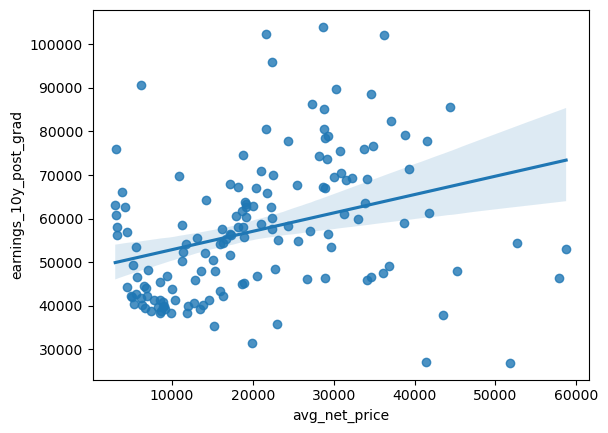

In [17]:
import seaborn as sns

sns.regplot(data=ny_colleges, x="avg_net_price",
            y="earnings_10y_post_grad")

In [18]:
unfiltered = pd.read_csv('colleges.csv')

In [19]:
ny_colleges_coords = ny_colleges.merge(unfiltered, how='left', on='id')
ny_colleges_coords.head()

,name,student_pop,acceptance_rate,avg_net_price,graduation_rate,earnings_10y_post_grad,city,ownership,id,latest.student.size,latest.admissions.admission_rate.overall,latest.cost.avg_net_price.overall,latest.completion.completion_rate_4yr_150nt,latest.earnings.10_yrs_after_entry.median,school.name,school.city,school.ownership,location.lat,location.lon
0,Adelphi University,5276,0.6591,30783.0,0.6715,75482.0,Garden City,2,188429,5276.0,0.6591,30783.0,0.6715,75482.0,Adelphi University,Garden City,2,40.721439,-73.653321
1,SUNY Adirondack,1844,NaN,10389.0,NaN,41267.0,Queensbury,1,188438,1844.0,NaN,10389.0,NaN,41267.0,SUNY Adirondack,Queensbury,1,43.351839,-73.654813
2,Alfred University,1423,0.7384,25620.0,0.5698,54897.0,Alfred,2,188641,1423.0,0.7384,25620.0,0.5698,54897.0,Alfred University,Alfred,2,42.254476,-77.788106
3,American Musical and Dramatic Academy,1438,0.2448,41416.0,0.7164,26975.0,New York,2,188854,1438.0,0.2448,41416.0,0.7164,26975.0,American Musical and Dramatic Academy,New York,2,40.772275,-73.987549
4,Bard College,2414,0.5212,34649.0,0.6756,46543.0,Annandale-On-Hudson,2,189088,2414.0,0.5212,34649.0,0.6756,46543.0,Bard College,Annandale-On-Hudson,2,42.020386,-73.909927


In [20]:
ny_colleges_coords = ny_colleges_coords.drop(columns={'latest.student.size', 'latest.admissions.admission_rate.overall', 'latest.cost.avg_net_price.overall', 'latest.completion.completion_rate_4yr_150nt', 'latest.earnings.10_yrs_after_entry.median', 'school.name', 'school.city', 'school.ownership'})

In [21]:
ny_colleges_coords.head()
missing = ny_colleges_coords[ny_colleges_coords['location.lat'].isna()]
missing.shape

(0, 11)

In [22]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    ny_colleges_coords,
    geometry = gpd.points_from_xy(ny_colleges_coords['location.lon'], ny_colleges_coords['location.lat']),
    crs = 'EPSG:4326'
)

<Axes: >

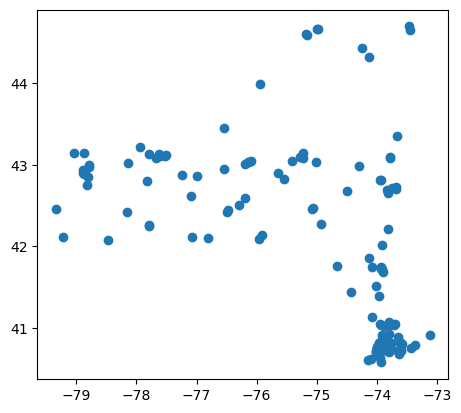

In [23]:
gdf.plot()

In [24]:
ownership_labels = {
    1: 'Public',
    2: 'Private nonprofit',
    3: 'Private for-profit'
}

gdf['ownership_label'] = gdf['ownership'].map(ownership_labels)

In [25]:
gdf.head()

gdf['name'] = gdf['name'].str.replace(
    r'\b(?:State University of New York at|SUNY at)\b',
    'SUNY',
    regex=True
)

In [26]:
gdf['ownership_label'] = gdf['ownership_label'].replace('Public', 'State/City University of New York')

In [27]:
gdf.to_file('colleges.geojson', driver='GeoJSON')